# ToneFit ML — Google Colab Pipeline

**FaRL vs DINOv2 for Personal Color Season Classification**
Dataset: Deep Armocromia (Stacchio et al., ECCV 2024)

---

**Before running:**
1. Go to `Runtime → Change runtime type → T4 GPU`
2. Mount Google Drive (Step 0) — dataset must be uploaded to Drive first

**Pipeline:**
1. Setup — mount Drive, clone repo, install dependencies
2. Link dataset from Drive
3. Preprocessing — extract CIELab/HSV features for EDA
4. EDA — visualize dataset
5. Train FaRL (Model A)
6. Train DINOv2 (Model B)
7. Evaluate — compare both models
8. Download results

---
## Step 0 — Check GPU

In [1]:
import torch

if torch.cuda.is_available():
    print(f'✅ GPU available: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('❌ No GPU detected!')
    print('Go to Runtime → Change runtime type → T4 GPU, then re-run.')

✅ GPU available: Tesla T4
   Memory: 15.6 GB


---
## Step 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted')

Mounted at /content/drive
✅ Google Drive mounted


---
## Step 2 — Clone Repo & Install Dependencies

In [3]:
import os

REPO_URL = 'https://github.com/ajipal/ToneFit.git'
REPO_DIR = '/content/ToneFit'

if os.path.isdir(REPO_DIR):
    print('Repo already cloned. Pulling latest...')
    !cd {REPO_DIR} && git pull
else:
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
print(f'✅ Working directory: {os.getcwd()}')
!ls

Cloning into '/content/ToneFit'...
remote: Enumerating objects: 2234, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 2234 (delta 13), reused 38 (delta 9), pack-reused 2189 (from 2)
Receiving objects: 100% (2234/2234), 319.86 MiB | 39.53 MiB/s, done.
Resolving deltas: 100% (16/16), done.
✅ Working directory: /content/ToneFit
annotations.csv  eda.ipynb	README.md	     train_farl.py
app.py		 evaluate.py	requirements.txt
claude.md	 outfits	ToneFit_Colab.ipynb
collectdata.py	 preprocess.py	train_dinov2.py


In [4]:
!pip install -q timm>=0.9.0 scikit-image imagehash
print('✅ Dependencies installed')

✅ Dependencies installed


---
## Step 3 — Link Dataset from Google Drive

> Update DRIVE_DATASET_PATH to where you uploaded RGB-M in Google Drive.

In [5]:
import os

# ── UPDATE THIS PATH to where RGB-M is in your Google Drive ──
DRIVE_DATASET_PATH = '/content/drive/MyDrive/ToneFit/RGB-M'

# Create symlink so scripts can use RGB-M/ directly
LOCAL_LINK = '/content/ToneFit/RGB-M'
if not os.path.exists(LOCAL_LINK):
    os.symlink(DRIVE_DATASET_PATH, LOCAL_LINK)
    print(f'✅ Linked: {LOCAL_LINK} → {DRIVE_DATASET_PATH}')
else:
    print(f'✅ RGB-M already linked')

# Verify structure
print('\nDataset structure:')
for split in ['train', 'test']:
    split_path = os.path.join(LOCAL_LINK, split)
    if os.path.exists(split_path):
        seasons = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        total = 0
        print(f'  {split}/')
        for season in sorted(seasons):
            count = sum(len(files) for _, _, files in os.walk(os.path.join(split_path, season)))
            total += count
            print(f'    {season}/: {count} images')
        print(f'    TOTAL: {total} images')
    else:
        print(f'  ❌ {split}/ not found at {split_path}')

✅ Linked: /content/ToneFit/RGB-M → /content/drive/MyDrive/ToneFit/RGB-M

Dataset structure:
  train/
    autumn/: 1046 images
    spring/: 978 images
    summer/: 943 images
    winter/: 1041 images
    TOTAL: 4008 images
  test/
    autumn/: 259 images
    spring/: 203 images
    summer/: 186 images
    winter/: 264 images
    TOTAL: 912 images


---
## Step 4 — Preprocessing (EDA Features Only)

> Extracts CIELab/HSV features from training images for EDA visualization.
> Does NOT re-split the dataset — RGB-M/train/ and RGB-M/test/ are used as-is.

In [6]:
import sys
if 'preprocess' in sys.modules:
    del sys.modules['preprocess']

import preprocess
preprocess.run()
print('✅ Preprocessing complete')

✅ Preprocessing complete


In [7]:
# Verify features.csv was created
import pandas as pd
df = pd.read_csv('features.csv')
print(f'features.csv: {len(df)} rows')
print('\nClass distribution:')
print(df['season'].value_counts())
print('\nSample:')
df.head()

features.csv: 3719 rows

Class distribution:
season
summer    1056
spring    1014
autumn     858
winter     791
Name: count, dtype: int64

Sample:


,filename,season,label,split,L_mean,a_mean,b_mean,L_std,a_std,b_std,ITA,H_mean,S_mean,V_mean,skin_ratio,blur_score
0,train/autumn/deep/10306.png,autumn,0,train,41.720249,14.184730,18.478388,27.622932,9.886711,13.126000,-24.136079,0.080230,0.431447,0.527067,0.360703,946.876884
1,train/autumn/deep/10552.png,autumn,0,train,50.542500,13.861103,17.949295,24.667582,7.803957,9.339136,1.731181,0.057641,0.367073,0.613669,0.360703,252.488540
2,train/autumn/deep/11113.png,autumn,0,train,42.051094,14.148452,22.190800,30.172569,7.285640,12.278474,-19.707893,0.063950,0.598398,0.537362,0.360703,760.105386
3,train/autumn/deep/11174.png,autumn,0,train,41.095085,14.983027,19.159258,23.675959,7.593022,9.643398,-24.928246,0.056728,0.518485,0.522496,0.360703,1056.014194
4,train/autumn/deep/11199.png,autumn,0,train,51.811565,16.982109,27.802258,22.671562,7.075937,9.382059,3.728062,0.066956,0.557358,0.652398,0.360703,1187.431498


---
## Step 5 — EDA

/tmp/ipykernel_12053/2389427829.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=[s.capitalize() for s in SEASONS], patch_artist=True)


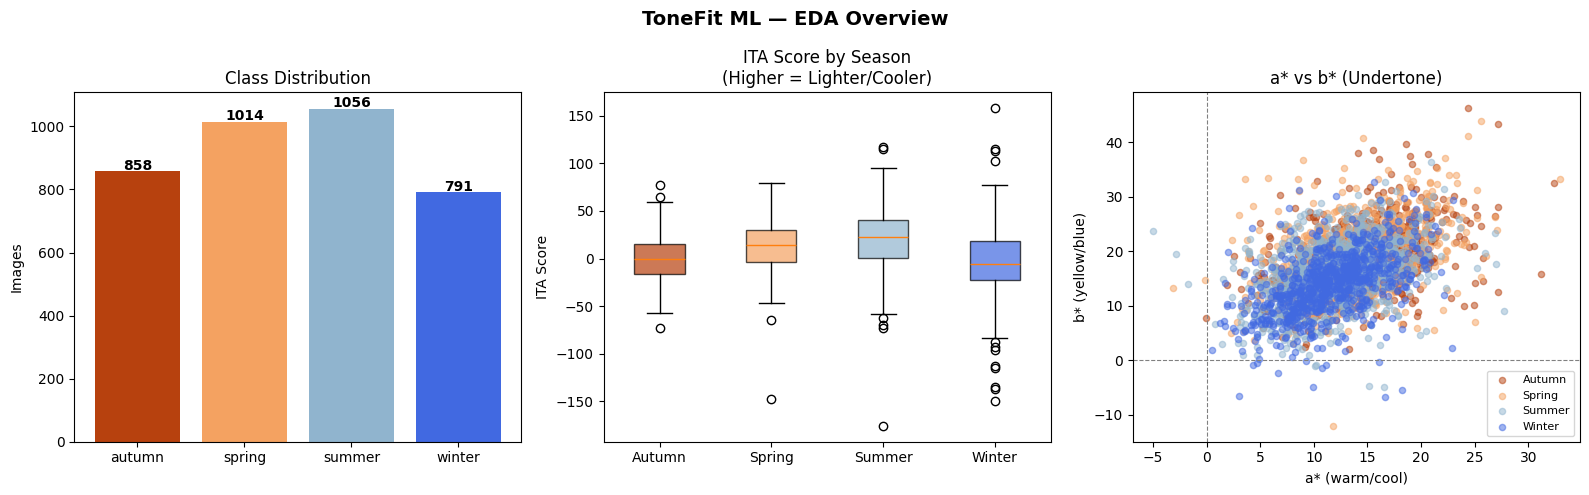

✅ EDA saved to results/eda_overview.png


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

os.makedirs('results', exist_ok=True)
df = pd.read_csv('features.csv')

SEASONS = ['autumn', 'spring', 'summer', 'winter']
COLORS  = {'autumn': '#B7410E', 'spring': '#F4A261', 'summer': '#90B4CE', 'winter': '#4169E1'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ToneFit ML — EDA Overview', fontsize=14, fontweight='bold')

# Class distribution
counts = df['season'].value_counts()[SEASONS]
axes[0].bar(counts.index, counts.values, color=[COLORS[s] for s in counts.index])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Images')
for i, (s, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ITA Score by season
data = [df[df['season'] == s]['ITA'].values for s in SEASONS]
bp = axes[1].boxplot(data, labels=[s.capitalize() for s in SEASONS], patch_artist=True)
for patch, s in zip(bp['boxes'], SEASONS):
    patch.set_facecolor(COLORS[s])
    patch.set_alpha(0.7)
axes[1].set_title('ITA Score by Season\n(Higher = Lighter/Cooler)')
axes[1].set_ylabel('ITA Score')

# a* vs b* scatter (undertone)
for s in SEASONS:
    sub = df[df['season'] == s]
    axes[2].scatter(sub['a_mean'], sub['b_mean'], label=s.capitalize(),
                    color=COLORS[s], alpha=0.5, s=20)
axes[2].axhline(0, color='gray', ls='--', lw=0.8)
axes[2].axvline(0, color='gray', ls='--', lw=0.8)
axes[2].set_title('a* vs b* (Undertone)')
axes[2].set_xlabel('a* (warm/cool)')
axes[2].set_ylabel('b* (yellow/blue)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA saved to results/eda_overview.png')

In [16]:
# Pull updated code
!cd /content/ToneFit && git pull

# Install CLIP (required for FaRL)
!pip install git+https://github.com/openai/CLIP.git -q

# Clear cached module
import sys
if 'train_farl' in sys.modules:
    del sys.modules['train_farl']

print('✅ FaRL code updated - ready to retrain')

remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 10 (delta 7), reused 7 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 2.33 KiB | 66.00 KiB/s, done.
From https://github.com/ajipal/ToneFit
   b5b3cd8..8bdce91  main       -> origin/main
Updating b5b3cd8..8bdce91
Fast-forward
 README.md       | 15 +++-------
 train_dinov2.py | 24 ++++++++--------
 train_farl.py   | 88 ++++++++++++++++++++++++++++++++++-----------------------
 3 files changed, 69 insertions(+), 58 deletions(-)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
✅ FaRL code updated - ready to retrain


---
## Step 6 — Train FaRL (Model A)

> **Person 1 runs this cell.**
> FaRL pretrained weights must be in `models/farl_weights.pth`
> Upload weights to Drive first, then copy to models/ folder.
> If weights not found, automatically falls back to ResNeXt50.
>
> Expected training time: ~20-40 minutes on T4 GPU

In [9]:
import os
os.makedirs('models', exist_ok=True)

!wget -q --show-progress -O models/farl_weights.pth \
  "https://github.com/FacePerceiver/FaRL/releases/download/pretrained_weights/FaRL-Base-Patch16-LAIONFace20M-ep64.pth"

print(f'✅ Done: {os.path.getsize("models/farl_weights.pth")/1e6:.0f} MB')

models/farl_weights 100%[===================>] 621.96M  74.2MB/s    in 11s     
✅ Done: 652 MB


In [10]:
import shutil
import os

# Save FaRL weights to Google Drive so you don't re-download next session
os.makedirs('/content/drive/MyDrive/ToneFit', exist_ok=True)

shutil.copy(
    'models/farl_weights.pth',
    '/content/drive/MyDrive/ToneFit/farl_weights.pth'
)

size = os.path.getsize('/content/drive/MyDrive/ToneFit/farl_weights.pth') / 1e6
print(f'✅ FaRL weights saved to Drive: {size:.0f} MB')
print('Next time — just copy from Drive instead of re-downloading')

✅ FaRL weights saved to Drive: 652 MB
Next time — just copy from Drive instead of re-downloading


In [11]:
# Optional: copy FaRL weights from Drive
import shutil
os.makedirs('models', exist_ok=True)

FARL_WEIGHTS_DRIVE = '/content/drive/MyDrive/ToneFit/farl_weights.pth'
FARL_WEIGHTS_LOCAL = 'models/farl_weights.pth'

if os.path.exists(FARL_WEIGHTS_DRIVE) and not os.path.exists(FARL_WEIGHTS_LOCAL):
    shutil.copy(FARL_WEIGHTS_DRIVE, FARL_WEIGHTS_LOCAL)
    print(f'✅ FaRL weights copied from Drive')
elif os.path.exists(FARL_WEIGHTS_LOCAL):
    print(f'✅ FaRL weights already in models/')
else:
    print('⚠️  FaRL weights not found — will use ResNeXt50 fallback')

✅ FaRL weights already in models/


In [ ]:
if 'train_farl' in sys.modules:
    del sys.modules['train_farl']

import train_farl
train_farl.main()
print('✅ FaRL training complete')

[INFO] Using device: cuda
  ToneFit — FaRL Personal Color Classifier (Model A)
[INFO] Classes detected: ['autumn', 'spring', 'summer', 'winter']
[INFO] Train samples: 4008
[INFO] Test  samples: 912

[INFO] Train class distribution:
  autumn  : 1046
  spring  : 978
  summer  : 943
  winter  : 1041
[INFO] Test class distribution:
  autumn  : 259
  spring  : 203
  summer  : 186
  winter  : 264

[INFO] Class weights: {'autumn': np.float64(0.9579), 'spring': np.float64(1.0245), 'summer': np.float64(1.0626), 'winter': np.float64(0.9625)}

[INFO] Train batches: 63
[INFO] Test  batches: 15

[INFO] Building model...
[INFO] FaRL weights found. Loading CLIP ViT-B/16 backbone...


100%|███████████████████████████████████████| 335M/335M [00:05<00:00, 64.7MiB/s]


[INFO] FaRL weights applied. Missing keys: 0, Unexpected: 17
[INFO] Backbone: FaRL (CLIP ViT-B/16, feature_dim=512)
[INFO] Trainable params: 132,356 / 86,324,996

[INFO] Starting training for 50 epochs...
[INFO] Backbone: FaRL (CLIP ViT-B/16, feature_dim=512)
----------------------------------------------------------------------
 Epoch  Train Loss  Train Acc  Val Loss   Val Acc          LR    Time
----------------------------------------------------------------------
     1      1.2277     0.4479    1.0762    0.5274    1.00e-03  163.5s <-- best
     2      1.0577     0.5372    1.0242    0.5384    9.76e-04  162.3s <-- best
     3      1.0340     0.5474    1.0344    0.5406    9.05e-04  161.9s <-- best
     4      1.0048     0.5594    1.0168    0.5526    7.96e-04  161.3s <-- best
     5      0.9939     0.5499    1.0255    0.5471    6.58e-04  160.1s
     6      0.9847     0.5676    1.0191    0.5439    5.05e-04  161.2s
     7      0.9628     0.5796    1.0176    0.5548    3.52e-04  161.3s <-

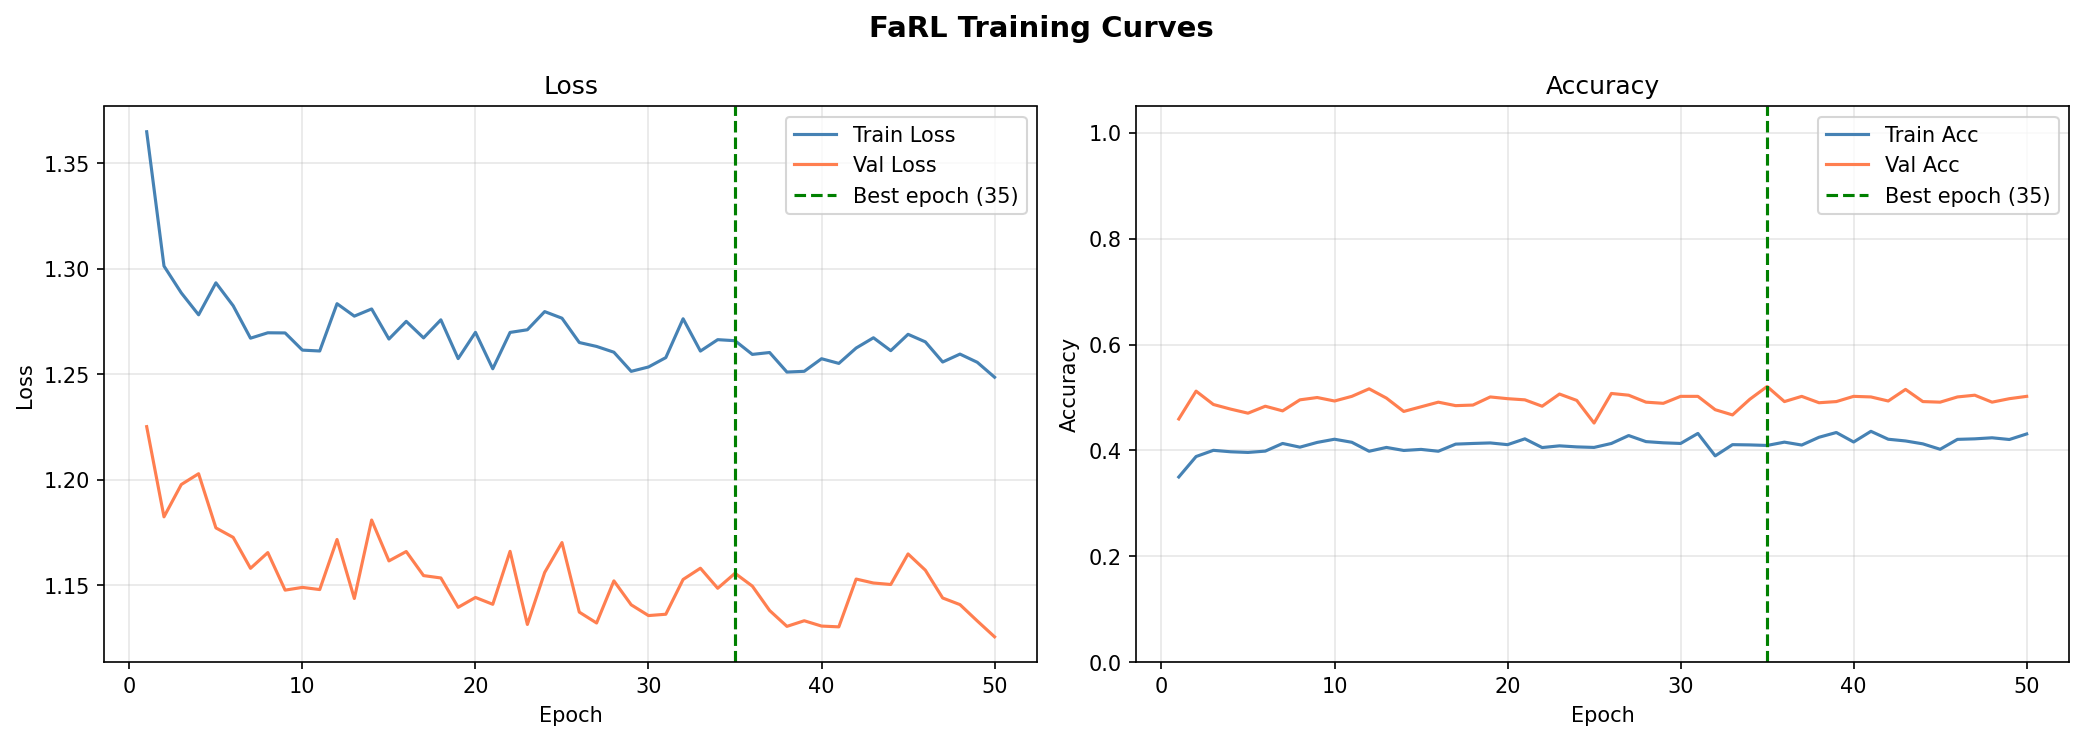

In [14]:
# Show FaRL training curves
from IPython.display import Image as IPImage, display
if os.path.exists('results/farl_training.png'):
    display(IPImage('results/farl_training.png'))
else:
    print('Training curves not found yet')

In [15]:
import shutil, glob, os

# Save models to Drive
os.makedirs('/content/drive/MyDrive/ToneFit/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ToneFit/results', exist_ok=True)

# Save FaRL model
shutil.copy('models/farl_model.pth',
            '/content/drive/MyDrive/ToneFit/models/farl_model.pth')

# Save all results
for f in glob.glob('results/*'):
    shutil.copy(f, '/content/drive/MyDrive/ToneFit/results/')

print('✅ All saved to Drive!')
print('You can now safely close Colab.')

✅ All saved to Drive!
You can now safely close Colab.


---
## Step 7 — Train DINOv2 (Model B)

> **Person 2 runs this cell in a separate Colab tab.**
> DINOv2 loads automatically from torch.hub — no weights to download.
>
> Expected training time: ~20-40 minutes on T4 GPU

In [ ]:
if 'train_dinov2' in sys.modules:
    del sys.modules['train_dinov2']

import train_dinov2
train_dinov2.run()
print('✅ DINOv2 training complete')

In [ ]:
# Show DINOv2 training curves
from IPython.display import Image as IPImage, display
if os.path.exists('results/dinov2_training.png'):
    display(IPImage('results/dinov2_training.png'))
else:
    print('Training curves not found yet')

---
## Step 8 — Evaluate Both Models

> Run AFTER both models are trained.
> Compares FaRL vs DINOv2 against paper baselines from Stacchio et al. (2024)

In [ ]:
if 'evaluate' in sys.modules:
    del sys.modules['evaluate']

import evaluate
evaluate.run()
print('✅ Evaluation complete')

In [ ]:
# Show comparison table
import pandas as pd
if os.path.exists('results/comparison_table.csv'):
    df_results = pd.read_csv('results/comparison_table.csv')
    print('\n===== MODEL COMPARISON =====')
    print(df_results.to_string(index=False))
else:
    print('comparison_table.csv not found')

In [ ]:
# Show confusion matrices and comparison chart
from IPython.display import Image as IPImage, display
for img in ['results/confusion_farl.png', 'results/confusion_dinov2.png', 'results/model_comparison.png']:
    if os.path.exists(img):
        print(f'\n{img}:')
        display(IPImage(img))
    else:
        print(f'❌ {img} not found')

---
## Step 9 — Save Results to Drive

In [ ]:
import shutil, glob

# Save to Google Drive
DRIVE_RESULTS = '/content/drive/MyDrive/ToneFit/results'
DRIVE_MODELS  = '/content/drive/MyDrive/ToneFit/models'
os.makedirs(DRIVE_RESULTS, exist_ok=True)
os.makedirs(DRIVE_MODELS, exist_ok=True)

# Copy results
for f in glob.glob('results/*'):
    shutil.copy(f, DRIVE_RESULTS)
print(f'✅ Results saved to Drive: {DRIVE_RESULTS}')

# Copy models
for f in glob.glob('models/*.pth'):
    shutil.copy(f, DRIVE_MODELS)
print(f'✅ Models saved to Drive: {DRIVE_MODELS}')

# Copy features.csv
if os.path.exists('features.csv'):
    shutil.copy('features.csv', '/content/drive/MyDrive/ToneFit/features.csv')
    print('✅ features.csv saved to Drive')

In [ ]:
# Also download as ZIP (optional)
import zipfile
from google.colab import files

zip_path = 'ToneFit_results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in glob.glob('results/*'):
        z.write(f)
    for f in glob.glob('models/*.pth'):
        z.write(f)
    if os.path.exists('features.csv'):
        z.write('features.csv')

size_mb = os.path.getsize(zip_path) / (1024*1024)
print(f'Created: {zip_path} ({size_mb:.1f} MB)')
files.download(zip_path)